In [13]:
import matplotlib.pyplot as plt
import numpy as np
import time
import os
import timeit
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'

# Automated histogram plot settings
xmin, xmax = -10, 10
num_bins = 100

def plot_histogram(counts, xmin=xmin, xmax=xmax, num_bins=num_bins, method_name="Method"):
    # Map bin counts to x-range [-10, 10]
    bin_width = (xmax - xmin) / num_bins
    x_left_edges = [xmin + i * bin_width for i in range(num_bins)]

    plt.figure(figsize=(10, 4))
    plt.bar(x_left_edges, counts, width=bin_width, align="edge", edgecolor="black")
    plt.xlim(xmin, xmax)
    plt.title(f"{method_name}: Histogram (x from {xmin} to {xmax}, {num_bins} bins)")
    plt.xlabel("x")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

def plot_strong_scaling(n, thread_counts, times, method_name="Method"):
    plt.figure(figsize=(7, 4))
    plt.plot(thread_counts, times, marker='o')
    plt.title(f"{method_name}: Strong Scaling: Runtime vs Number of Threads for n = 1e{int(np.log10(n))}")
    plt.xlabel("Number of Threads")
    plt.ylabel("Runtime (seconds)")
    plt.xticks(thread_counts)
    plt.grid()
    plt.tight_layout()
    plt.show()

def plot_weak_scaling(n, thread_counts, times, method_name="Method"):
    plt.figure(figsize=(7, 4))
    plt.plot(thread_counts, times, marker='o')
    plt.title(f"{method_name}: Weak Scaling: Runtime vs Number of Threads for n = 1e{int(np.log10(n))} per thread")
    plt.xlabel("Number of Threads")
    plt.ylabel("Runtime (seconds)")
    plt.xticks(thread_counts)
    plt.grid()
    plt.tight_layout()
    plt.show()


# Testing with visualize histogram

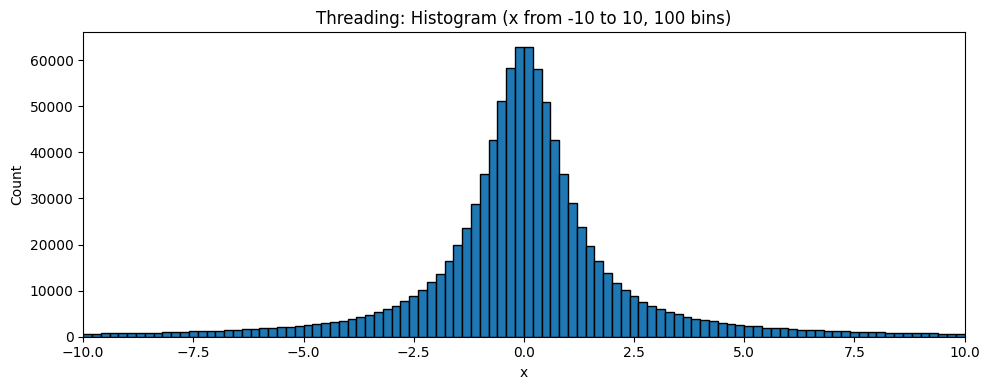

In [2]:
import thread_lorentz

n = 1e6
method_name = "Threading"
# Get counts for histogram from one execution
local_counts, _ = thread_lorentz.run_threaded(n, n_threads=1,)
plot_histogram(local_counts, method_name=method_name)


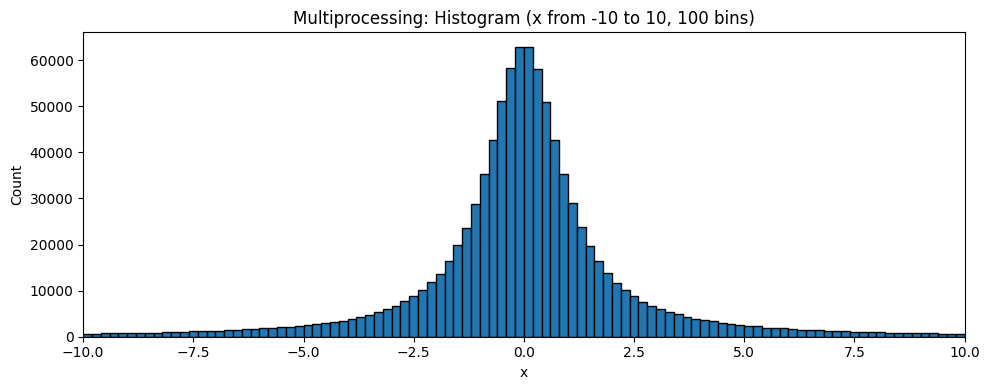

In [3]:
import mp_lorentz

n = 1e6
method_name = "Multiprocessing"
# Get counts for histogram from one execution
local_counts = mp_lorentz.run_multiproc(n, n_cores=1)
plot_histogram(local_counts, method_name=method_name)


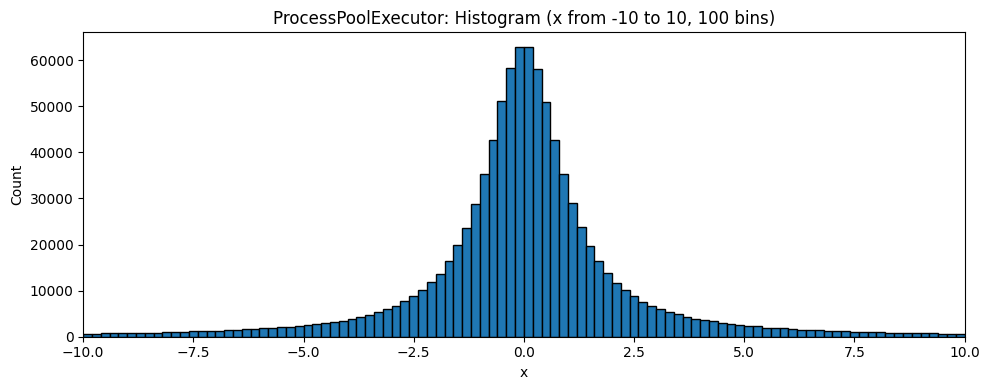

In [4]:
import ppe_lorentz

n = 1e6
method_name = "ProcessPoolExecutor"
# Get counts for histogram from one execution
local_counts = ppe_lorentz.run_ppe(n, max_workers=1)
plot_histogram(local_counts, method_name=method_name)

Results shapes: (1, 100)


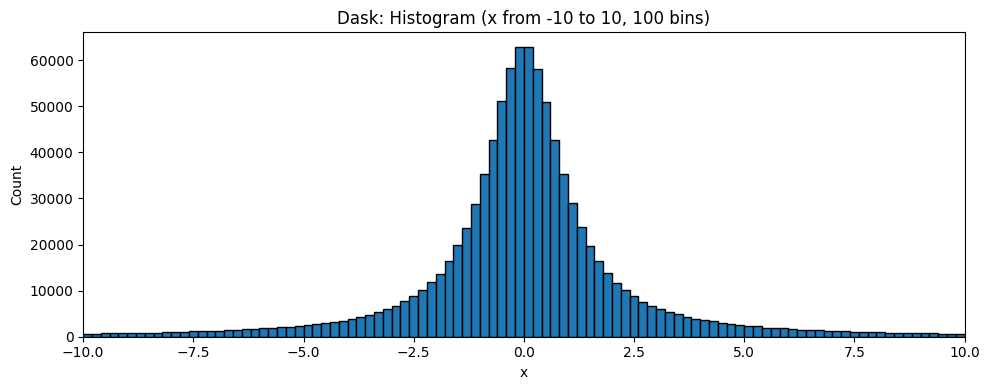

In [5]:
import dask_lorentz

n= 1e6
method_name = "Dask"
# Get counts for histogram from one execution
local_counts = dask_lorentz.run_dask(n, n_tasks=1)
plot_histogram(local_counts, method_name=method_name)

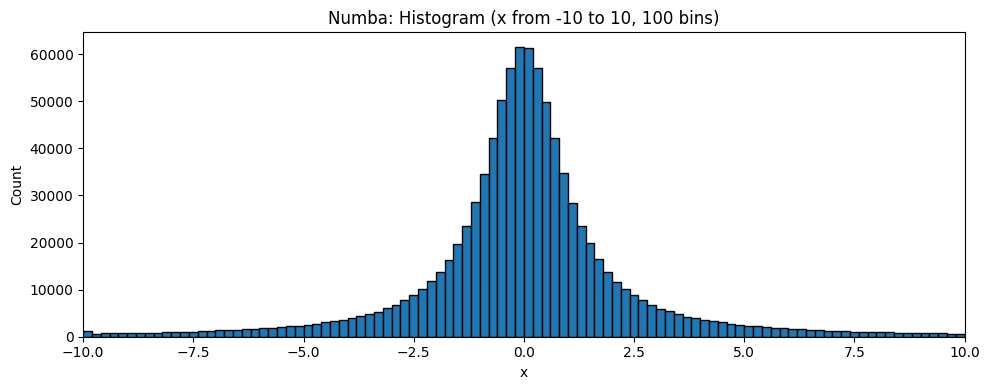

In [7]:
import numba_lorentz
n = 1e6
method_name = "Numba"
# Get counts for histogram from one execution
local_counts = numba_lorentz.lorentzian_histogram_numba(n)
plot_histogram(local_counts, method_name=method_name)

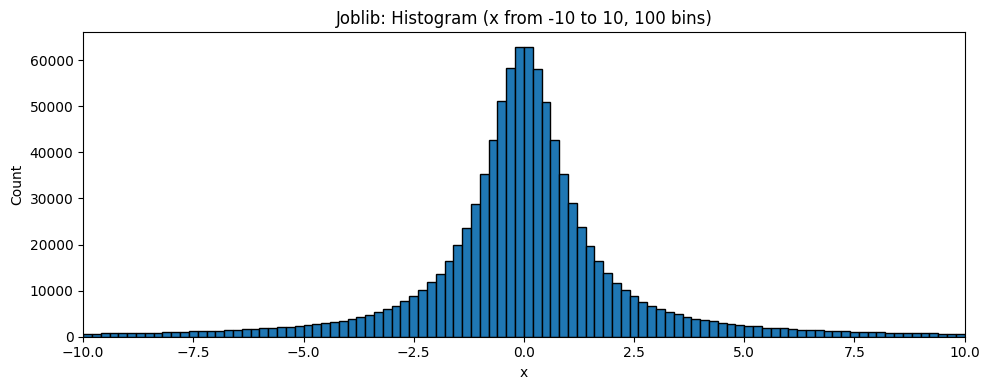

In [29]:
import joblib_lorentz

n = 1e6
method_name = "Joblib"
# Get counts for histogram from one execution
local_counts = joblib_lorentz.run_joblib(n, n_jobs=1)
plot_histogram(local_counts, method_name=method_name)

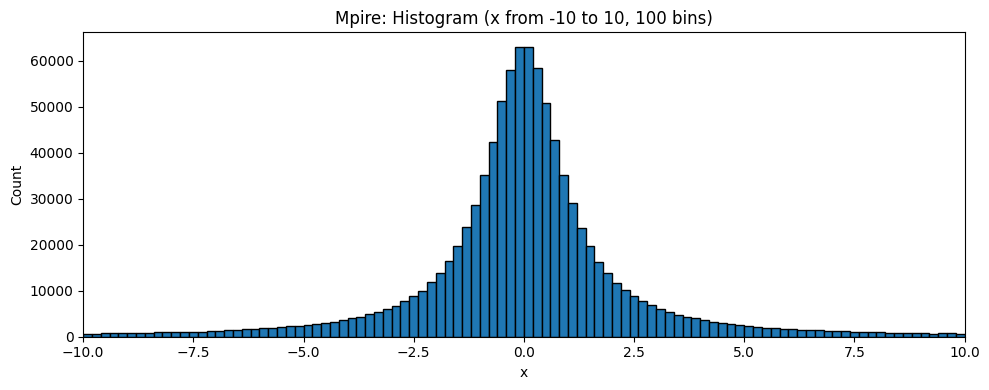

In [30]:
import mpire_lorentz
n = 1e6
method_name = "Mpire"
# Get counts for histogram from one execution
local_counts = mpire_lorentz.run_mpire(n, n_jobs=1)
plot_histogram(local_counts, method_name=method_name)

# Threading

Time taken with 1 threads: 0.2532 seconds (avg of 5 runs)
Time taken with 2 threads: 0.1366 seconds (avg of 5 runs)
Time taken with 4 threads: 0.1043 seconds (avg of 5 runs)
Time taken with 8 threads: 0.0982 seconds (avg of 5 runs)
Time taken with 16 threads: 0.0983 seconds (avg of 5 runs)
Time taken with 32 threads: 0.0927 seconds (avg of 5 runs)


<Figure size 700x600 with 0 Axes>

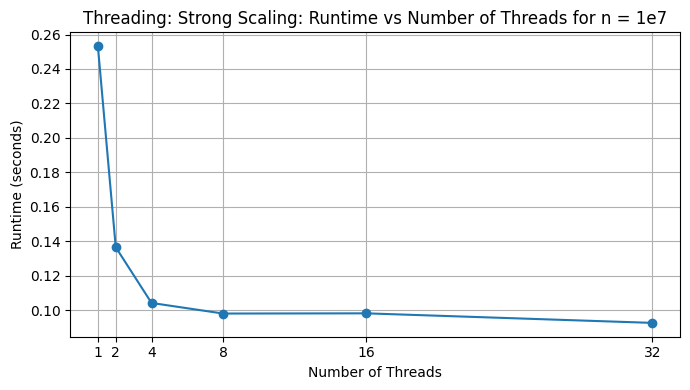

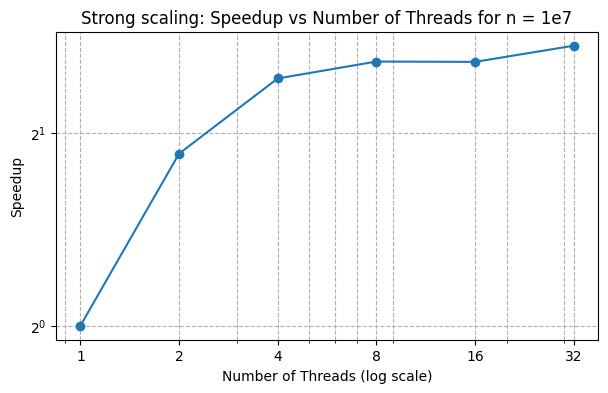

<Figure size 640x480 with 0 Axes>

In [11]:
import timeit
import thread_lorentz 
#Strong Scaling
n=1e7
times=[]
thread_counts = [1, 2, 4, 8, 16, 32]
local_dry_run = thread_lorentz.run_threaded(1e6, n_threads=1)  # Warmup run to initialize threading
del local_dry_run  # Free memory from warmup run
for n_threads in thread_counts:
    def run_once():
        return thread_lorentz.run_threaded(n, n_threads=n_threads)
    
    total_time = timeit.timeit(run_once, number=5)
    avg_time = total_time / 5
    times.append(avg_time)
    print(f"Time taken with {n_threads} threads: {avg_time:.4f} seconds (avg of 5 runs)")

#plot run time vs parallelism
plt.figure(figsize=(7, 6))

plot_strong_scaling(n, thread_counts, times, method_name="Threading")

#plot speedup vs parallelism
plt.figure(figsize=(7, 4))
speedup = [times[0] / t for t in times]
plt.plot(thread_counts, speedup, marker='o')
plt.xscale('log', base=10)
plt.yscale('log', base=2)
plt.xlabel('Number of Threads (log scale)')
plt.ylabel('Speedup')
plt.title(f'Strong scaling: Speedup vs Number of Threads for n = 1e{int(np.log10(n))}')
plt.grid(True, which="both", ls="--")

plt.xticks(thread_counts, thread_counts)
plt.show()
plt.tight_layout()

Time taken with 1 threads: 0.2521 seconds (avg of 5 runs)
Time taken with 2 threads: 0.3308 seconds (avg of 5 runs)
Time taken with 4 threads: 0.4574 seconds (avg of 5 runs)
Time taken with 8 threads: 0.8310 seconds (avg of 5 runs)
Time taken with 16 threads: 1.8858 seconds (avg of 5 runs)


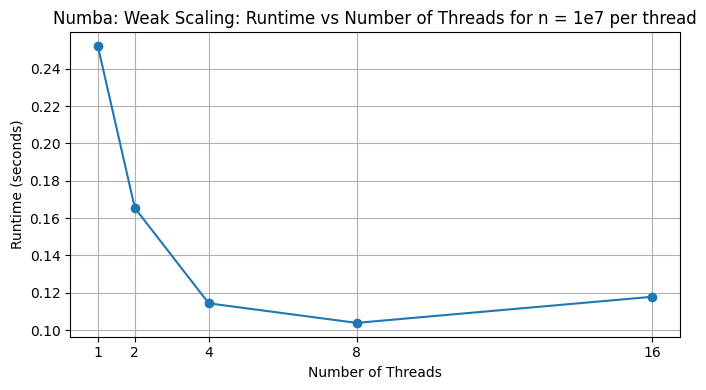

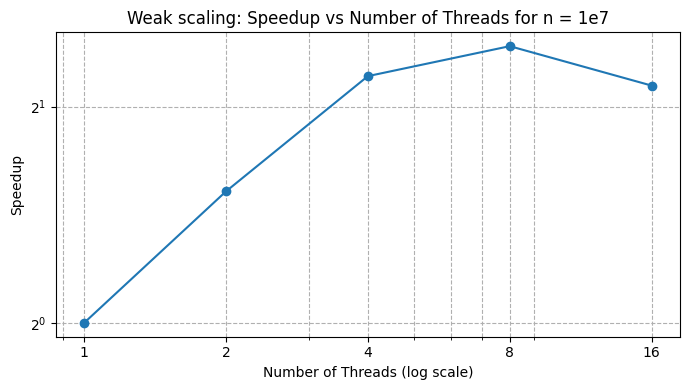

In [14]:
#Weak Scaling
n=1e7
times=[]
thread_counts = [1, 2, 4, 8, 16]
for n_threads in thread_counts:
    def run_once():
        return thread_lorentz.run_threaded(n*n_threads, n_threads=n_threads)
    
    total_time = timeit.timeit(run_once, number=5)
    avg_time = total_time / 5
    times.append(avg_time/n_threads)  # Normalize by number of threads for weak scaling
    print(f"Time taken with {n_threads} threads: {avg_time:.4f} seconds (avg of 5 runs)")

plot_weak_scaling(n, thread_counts, times, method_name=method_name)


#plot speedup vs parallelism
plt.figure(figsize=(7, 4))
speedup = [times[0] / t for t in times]
plt.plot(thread_counts, speedup, marker='o')
plt.xscale('log', base=10)
plt.yscale('log', base=2)
plt.xlabel('Number of Threads (log scale)')
plt.ylabel('Speedup')
plt.title(f'Weak scaling: Speedup vs Number of Threads for n = 1e{int(np.log10(n))}')
plt.grid(True, which="both", ls="--")
plt.xticks(thread_counts, thread_counts)
plt.tight_layout()
plt.show()

# Multiprocessing module

Time taken with 1 threads: 2.6348 seconds (avg of 5 runs)
Time taken with 2 threads: 1.3578 seconds (avg of 5 runs)
Time taken with 4 threads: 1.0663 seconds (avg of 5 runs)


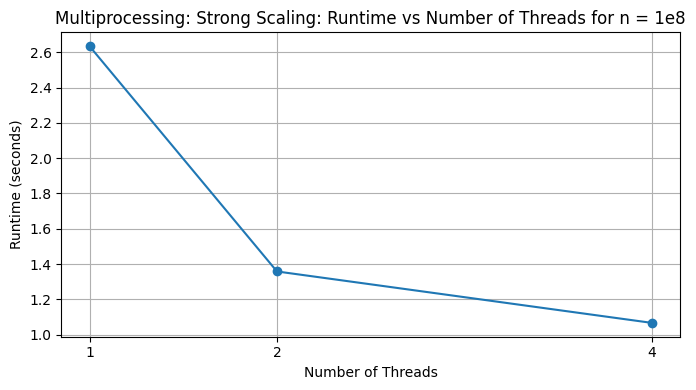

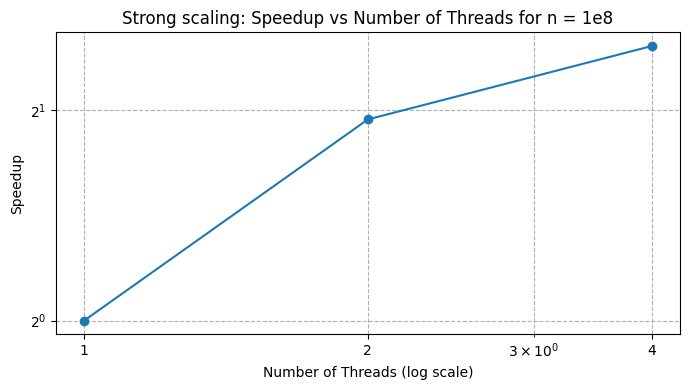

In [16]:
import mp_lorentz

import matplotlib.pyplot as plt

#Strong Scaling
n=1e8
times=[]
thread_counts = [1, 2, 4]
#Warmup run to initialize multiprocessing
local_counts = mp_lorentz.run_multiproc(1e6, n_cores=1)
for n_threads in thread_counts:
    def run_once():
        return mp_lorentz.run_multiproc(n, n_cores=n_threads)
    
    total_time = timeit.timeit(run_once, number=5)
    avg_time = total_time / 5
    times.append(avg_time)
    print(f"Time taken with {n_threads} threads: {avg_time:.4f} seconds (avg of 5 runs)")

plot_strong_scaling(n, thread_counts, times, method_name="Multiprocessing")

# plot speedup vs parallelism
plt.figure(figsize=(7, 4))
speedup = [times[0] / t for t in times]
plt.plot(thread_counts, speedup, marker='o')
plt.xscale('log', base=10)
plt.yscale('log', base=2)
plt.xlabel('Number of Threads (log scale)')
plt.ylabel('Speedup')
plt.title(f'Strong scaling: Speedup vs Number of Threads for n = 1e{int(np.log10(n))}')
plt.grid(True, which="both", ls="--")
plt.xticks(thread_counts, thread_counts)
plt.tight_layout()
plt.show()

Time taken with 1 threads: 0.3057 seconds (avg of 5 runs)
Time taken with 2 threads: 0.3231 seconds (avg of 5 runs)
Time taken with 4 threads: 0.3943 seconds (avg of 5 runs)


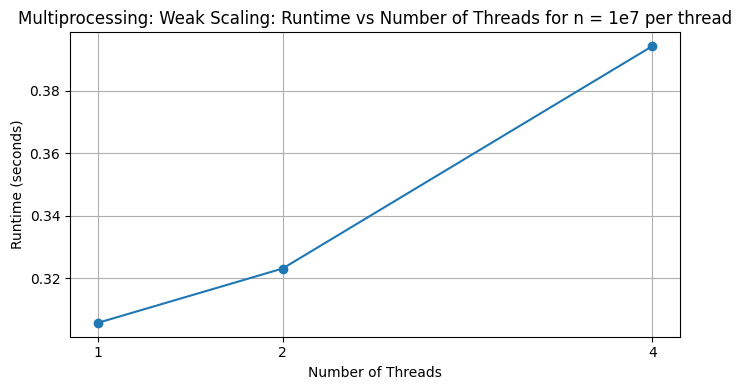

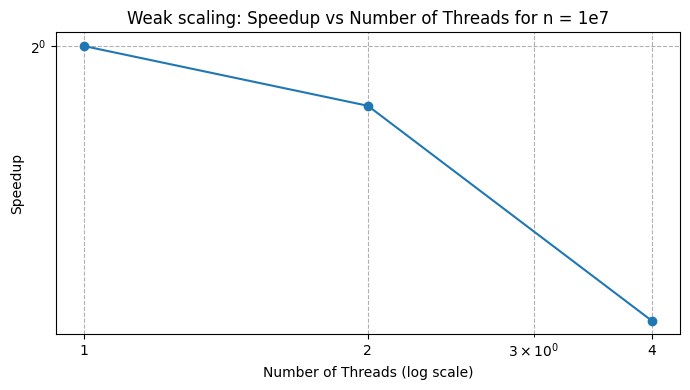

In [17]:
#Weak Scaling
n=1e7
times=[]
thread_counts = [1, 2, 4]
for n_threads in thread_counts:
    def run_once():
        return mp_lorentz.run_multiproc(n*n_threads, n_cores=n_threads)
    
    total_time = timeit.timeit(run_once, number=5)
    avg_time = total_time / 5
    times.append(avg_time)
    print(f"Time taken with {n_threads} threads: {avg_time:.4f} seconds (avg of 5 runs)")


plot_weak_scaling(n, thread_counts, times, method_name="Multiprocessing")
# plot speedup vs parallelism
plt.figure(figsize=(7, 4))
speedup = [times[0] / t for t in times]
plt.plot(thread_counts, speedup, marker='o')
plt.xscale('log', base=10)
plt.yscale('log', base=2)
plt.xlabel('Number of Threads (log scale)')
plt.ylabel('Speedup')
plt.title(f'Weak scaling: Speedup vs Number of Threads for n = 1e{int(np.log10(n))}')
plt.grid(True, which="both", ls="--")
plt.xticks(thread_counts, thread_counts)
plt.tight_layout()
plt.show()


# ProcessPoolExecutor

Time taken with 1 threads: 0.3277 seconds (avg of 5 runs)
Time taken with 2 threads: 0.2530 seconds (avg of 5 runs)
Time taken with 4 threads: 0.2690 seconds (avg of 5 runs)


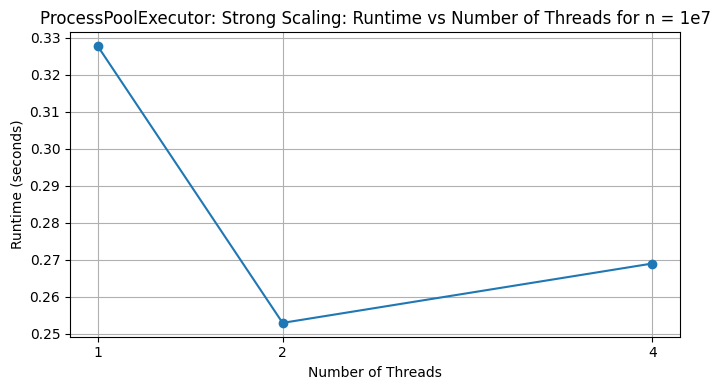

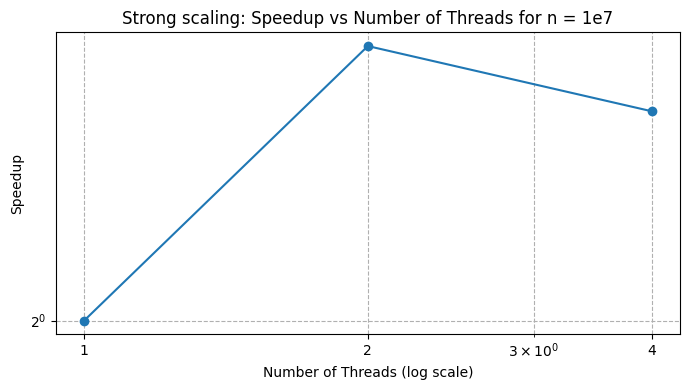

In [18]:
import ppe_lorentz

import matplotlib.pyplot as plt

#Strong Scaling
n=1e7
times=[]
thread_counts = [1, 2, 4]
#Warmup run to initialize multiprocessing
local_dry_run = ppe_lorentz.run_ppe(1e6, max_workers=1)
del local_dry_run  # Free memory from warmup run
for n_threads in thread_counts:
    def run_once():
        return ppe_lorentz.run_ppe(n, max_workers=n_threads)
    
    total_time = timeit.timeit(run_once, number=5)
    avg_time = total_time / 5
    times.append(avg_time)
    print(f"Time taken with {n_threads} threads: {avg_time:.4f} seconds (avg of 5 runs)")


plot_strong_scaling(n, thread_counts, times, method_name="ProcessPoolExecutor")

# plot speedup vs parallelism
plt.figure(figsize=(7, 4))
speedup = [times[0] / t for t in times]
plt.plot(thread_counts, speedup, marker='o')
plt.xscale('log', base=10)
plt.yscale('log', base=2)
plt.xlabel('Number of Threads (log scale)')
plt.ylabel('Speedup')
plt.title(f'Strong scaling: Speedup vs Number of Threads for n = 1e{int(np.log10(n))}')
plt.grid(True, which="both", ls="--")
plt.xticks(thread_counts, thread_counts)
plt.tight_layout()
plt.show()

Time taken with 1 threads: 0.3267 seconds (avg of 5 runs)
Time taken with 2 threads: 0.3497 seconds (avg of 5 runs)
Time taken with 4 threads: 0.4459 seconds (avg of 5 runs)


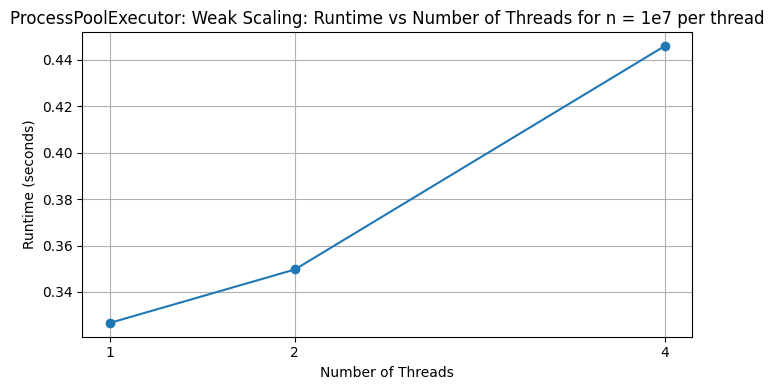

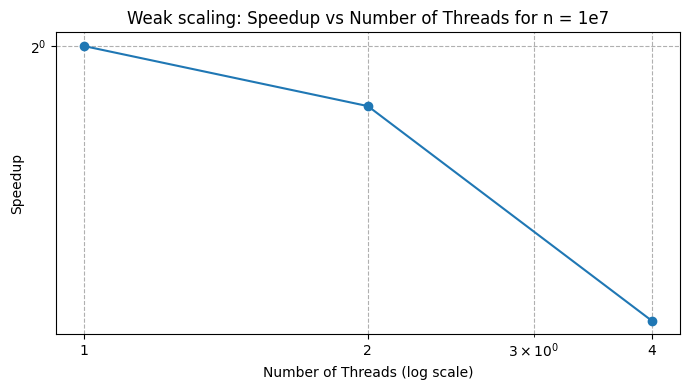

In [19]:
#Weak Scaling
n=1e7
times=[]
thread_counts = [1, 2, 4]
#Warmup run to initialize multiprocessing
local_dry_run = ppe_lorentz.run_ppe(1e6, max_workers=1)
del local_dry_run  # Free memory from warmup run
for n_threads in thread_counts:
    def run_once():
        return ppe_lorentz.run_ppe(n*n_threads, max_workers=n_threads)
    
    total_time = timeit.timeit(run_once, number=5)
    avg_time = total_time / 5
    times.append(avg_time)
    print(f"Time taken with {n_threads} threads: {avg_time:.4f} seconds (avg of 5 runs)")

plot_weak_scaling(n, thread_counts, times, method_name="ProcessPoolExecutor")

# plot speedup vs parallelism
plt.figure(figsize=(7, 4))
speedup = [times[0] / t for t in times]
plt.plot(thread_counts, speedup, marker='o')
plt.xscale('log', base=10)
plt.yscale('log', base=2)
plt.xlabel('Number of Threads (log scale)')
plt.ylabel('Speedup')
plt.title(f'Weak scaling: Speedup vs Number of Threads for n = 1e{int(np.log10(n))}')
plt.grid(True, which="both", ls="--")
plt.xticks(thread_counts, thread_counts)
plt.tight_layout()
plt.show()

# Asyncio

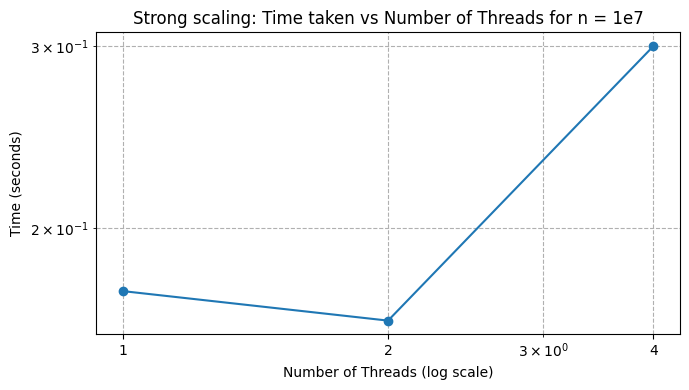

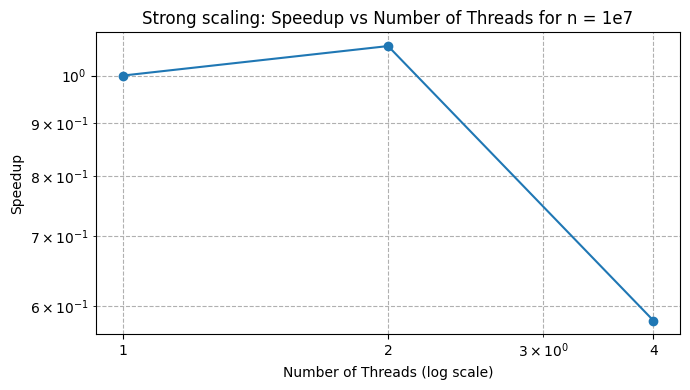

In [11]:
import matplotlib.pyplot as plt

data = np.loadtxt("async_lorentzian_strong_scaling_times.txt")
thread_counts = data[:, 0].astype(int)
times = data[:, 1]

#plot runtime vs parallelism

plt.figure(figsize=(7, 4))
plt.plot(thread_counts, times, marker='o')
plt.xscale('log', base=10)
plt.yscale('log', base=10)
plt.xlabel('Number of Threads (log scale)')
plt.ylabel('Time (seconds)')
plt.title(f'Strong scaling: Time taken vs Number of Threads for n = 1e{int(np.log10(n))}')
plt.grid(True, which="both", ls="--")
plt.xticks(thread_counts, thread_counts)
plt.tight_layout()
plt.show()

#plot speedup vs parallelism
plt.figure(figsize=(7, 4))
speedup = [times[0] / t for t in times]
plt.plot(thread_counts, speedup, marker='o')
plt.xscale('log', base=10)
plt.yscale('log', base=10)
plt.xlabel('Number of Threads (log scale)')
plt.ylabel('Speedup')
plt.title(f'Strong scaling: Speedup vs Number of Threads for n = 1e{int(np.log10(n))}')
plt.grid(True, which="both", ls="--")
plt.xticks(thread_counts, thread_counts)
plt.tight_layout()
plt.show()

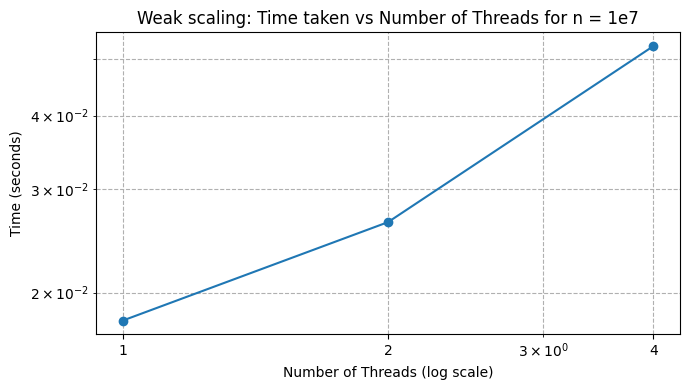

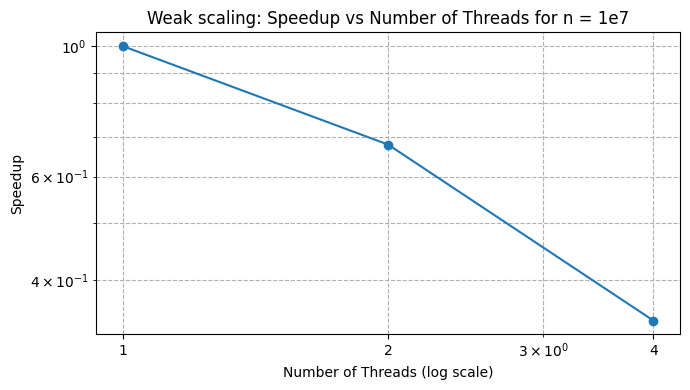

In [12]:
#Weak Scaling
data = np.loadtxt("async_lorentzian_weak_scaling_times.txt")
thread_counts = data[:, 0].astype(int)
times = data[:, 1]
#plot runtime vs parallelism
plt.figure(figsize=(7, 4))
plt.plot(thread_counts, times, marker='o')
plt.xscale('log', base=10)
plt.yscale('log', base=10)
plt.xlabel('Number of Threads (log scale)')
plt.ylabel('Time (seconds)')
plt.title(f'Weak scaling: Time taken vs Number of Threads for n = 1e{int(np.log10(n))}')
plt.grid(True, which="both", ls="--")
plt.xticks(thread_counts, thread_counts)
plt.tight_layout()
plt.show()

#plot speedup vs parallelism
plt.figure(figsize=(7, 4))
speedup = [times[0] / t for t in times]
plt.plot(thread_counts, speedup, marker='o')
plt.xscale('log', base=10)
plt.yscale('log', base=10)
plt.xlabel('Number of Threads (log scale)')
plt.ylabel('Speedup')
plt.title(f'Weak scaling: Speedup vs Number of Threads for n = 1e{int(np.log10(n))}')
plt.grid(True, which="both", ls="--")
plt.xticks(thread_counts, thread_counts)
plt.tight_layout()
plt.show()

# Dask

Results shapes: (1, 100)
Results shapes: (1, 100)
Results shapes: (1, 100)
Results shapes: (1, 100)
Results shapes: (1, 100)
Results shapes: (1, 100)
Time taken with 1 threads: 0.2140 seconds (avg of 5 runs)
Results shapes: (2, 100)
Results shapes: (2, 100)
Results shapes: (2, 100)
Results shapes: (2, 100)
Results shapes: (2, 100)
Time taken with 2 threads: 0.1729 seconds (avg of 5 runs)
Results shapes: (4, 100)
Results shapes: (4, 100)
Results shapes: (4, 100)
Results shapes: (4, 100)
Results shapes: (4, 100)
Time taken with 4 threads: 0.1018 seconds (avg of 5 runs)


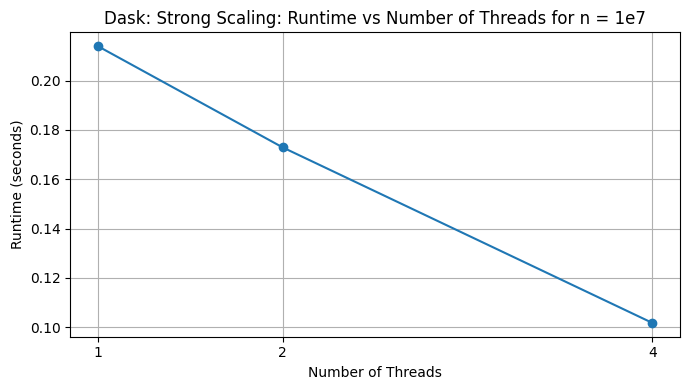

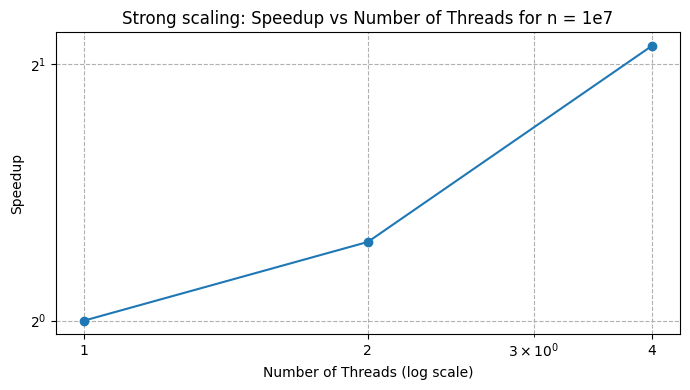

In [20]:
import dask_lorentz

import matplotlib.pyplot as plt

#Strong Scaling
n=1e7
times=[]
thread_counts = [1, 2, 4]
#WARMUP RUN
local_dry_run = dask_lorentz.run_dask(n, n_tasks=1)  # Warmup run to initialize Dask
del local_dry_run  # Free memory from warmup run
for n_threads in thread_counts:
    def run_once():
        return dask_lorentz.run_dask(n, n_tasks=n_threads)
    
    total_time = timeit.timeit(run_once, number=5)
    avg_time = total_time / 5
    times.append(avg_time)
    print(f"Time taken with {n_threads} threads: {avg_time:.4f} seconds (avg of 5 runs)")

plot_strong_scaling(n, thread_counts, times, method_name="Dask")

# plot speedup vs parallelism
plt.figure(figsize=(7, 4))
speedup = [times[0] / t for t in times]
plt.plot(thread_counts, speedup, marker='o')
plt.xscale('log', base=10)
plt.yscale('log', base=2)
plt.xlabel('Number of Threads (log scale)')
plt.ylabel('Speedup')
plt.title(f'Strong scaling: Speedup vs Number of Threads for n = 1e{int(np.log10(n))}')
plt.grid(True, which="both", ls="--")
plt.xticks(thread_counts, thread_counts)
plt.tight_layout()
plt.show()

Results shapes: (1, 100)
Results shapes: (1, 100)
Results shapes: (1, 100)
Results shapes: (1, 100)
Results shapes: (1, 100)
Results shapes: (1, 100)
Time taken with 1 threads: 0.2091 seconds (avg of 5 runs)
Results shapes: (2, 100)
Results shapes: (2, 100)
Results shapes: (2, 100)
Results shapes: (2, 100)
Results shapes: (2, 100)
Time taken with 2 threads: 0.2719 seconds (avg of 5 runs)
Results shapes: (4, 100)
Results shapes: (4, 100)
Results shapes: (4, 100)
Results shapes: (4, 100)
Results shapes: (4, 100)
Time taken with 4 threads: 0.4815 seconds (avg of 5 runs)


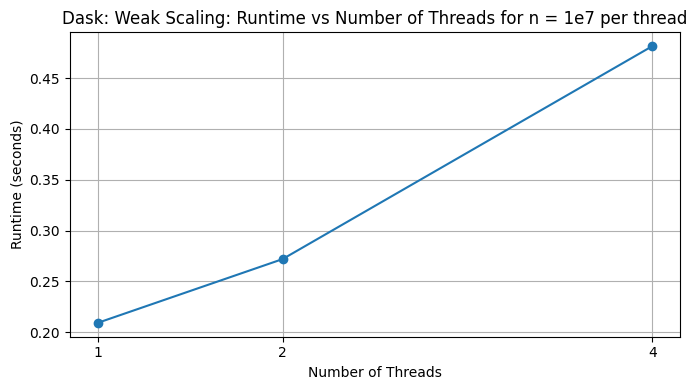

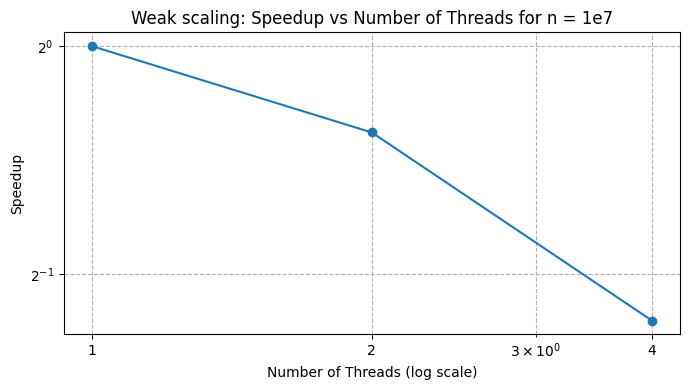

In [22]:
# Weak Scaling
n=1e7
times=[]
thread_counts = [1, 2, 4]
#WARMUP RUN to initialize Dask
local_dry_run = dask_lorentz.run_dask(n, n_tasks=1)
del local_dry_run  # Free memory from warmup run
for n_threads in thread_counts:
    def run_once():
        return dask_lorentz.run_dask(n*n_threads, n_tasks=n_threads)
    
    total_time = timeit.timeit(run_once, number=5)
    avg_time = total_time / 5
    times.append(avg_time)
    print(f"Time taken with {n_threads} threads: {avg_time:.4f} seconds (avg of 5 runs)")

plot_weak_scaling(n, thread_counts, times, method_name="Dask")

# plot speedup vs parallelism
plt.figure(figsize=(7, 4))
speedup = [times[0] / t for t in times]
plt.plot(thread_counts, speedup, marker='o')
plt.xscale('log', base=10)
plt.yscale('log', base=2)
plt.xlabel('Number of Threads (log scale)')
plt.ylabel('Speedup')
plt.title(f'Weak scaling: Speedup vs Number of Threads for n = 1e{int(np.log10(n))}')
plt.grid(True, which="both", ls="--")
plt.xticks(thread_counts, thread_counts)
plt.tight_layout()
plt.show()

# joblib

Time taken with 1 threads: 0.2049 seconds (avg of 5 runs)
Time taken with 2 threads: 0.2137 seconds (avg of 5 runs)
Time taken with 4 threads: 0.1934 seconds (avg of 5 runs)


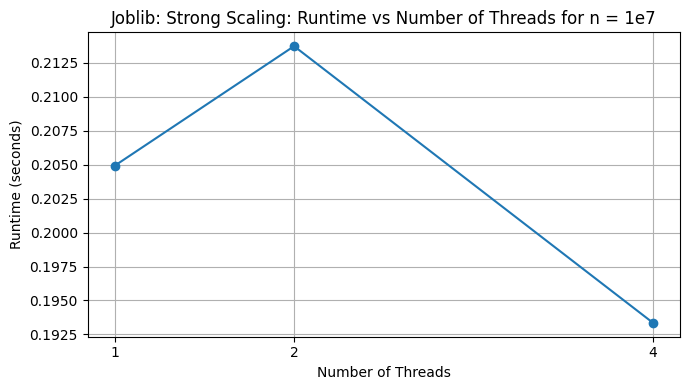

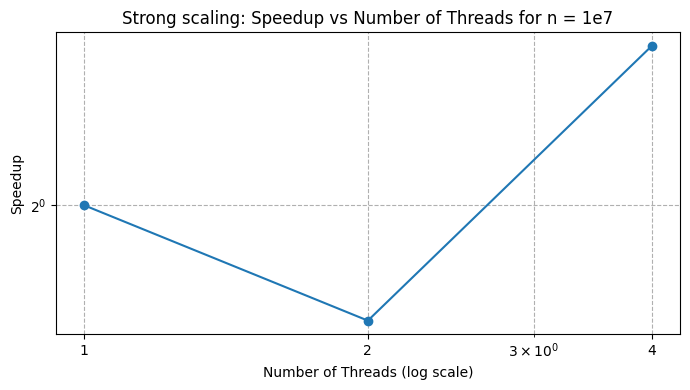

In [23]:
import joblib_lorentz

import matplotlib.pyplot as plt

#Strong Scaling
n=1e7
times=[]
thread_counts = [1, 2, 4]
#WARMUP RUN
local_dry_run = joblib_lorentz.run_joblib(1e7, n_jobs=1)  # Warmup run to initialize Joblib
del local_dry_run  # Free memory from warmup run
for n_threads in thread_counts:
    def run_once():
        return joblib_lorentz.run_joblib(n, n_jobs=n_threads)
    
    total_time = timeit.timeit(run_once, number=5)
    avg_time = total_time / 5
    times.append(avg_time)
    print(f"Time taken with {n_threads} threads: {avg_time:.4f} seconds (avg of 5 runs)")

plot_strong_scaling(n, thread_counts, times, method_name="Joblib")

# plot speedup vs parallelism
plt.figure(figsize=(7, 4))
speedup = [times[0] / t for t in times]
plt.plot(thread_counts, speedup, marker='o')
plt.xscale('log', base=10)
plt.yscale('log', base=2)
plt.xlabel('Number of Threads (log scale)')
plt.ylabel('Speedup')
plt.title(f'Strong scaling: Speedup vs Number of Threads for n = 1e{int(np.log10(n))}')
plt.grid(True, which="both", ls="--")
plt.xticks(thread_counts, thread_counts)
plt.tight_layout()
plt.show()

Time taken with 1 threads: 0.2220 seconds (avg of 5 runs)
Time taken with 2 threads: 0.3731 seconds (avg of 5 runs)
Time taken with 4 threads: 0.3640 seconds (avg of 5 runs)


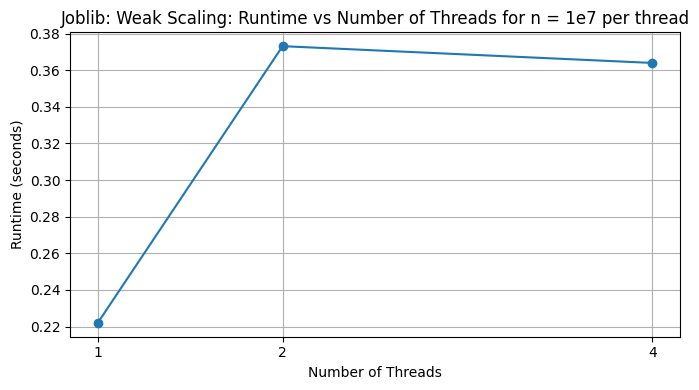

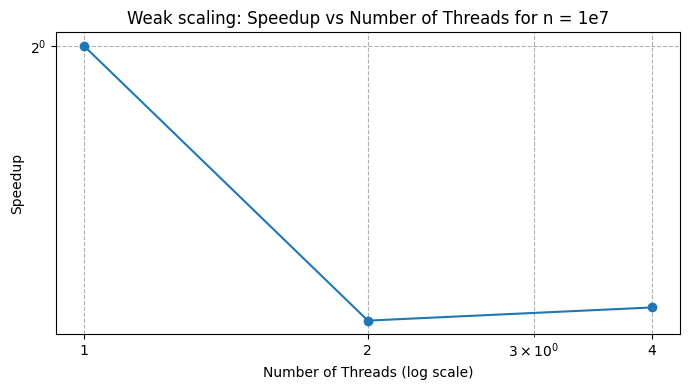

In [24]:
# Weak Scaling
n=1e7
times=[]
thread_counts = [1, 2, 4]
#WARMUP RUN to initialize Joblib
local_dry_run = joblib_lorentz.run_joblib(n, n_jobs=1)
del local_dry_run  # Free memory from warmup run
for n_threads in thread_counts:
    def run_once():
        return joblib_lorentz.run_joblib(n*n_threads, n_jobs=n_threads)
    
    total_time = timeit.timeit(run_once, number=5)
    avg_time = total_time / 5
    times.append(avg_time)
    print(f"Time taken with {n_threads} threads: {avg_time:.4f} seconds (avg of 5 runs)")

plot_weak_scaling(n, thread_counts, times, method_name="Joblib")

# plot speedup vs parallelism
plt.figure(figsize=(7, 4))
speedup = [times[0] / t for t in times]
plt.plot(thread_counts, speedup, marker='o')
plt.xscale('log', base=10)
plt.yscale('log', base=2)
plt.xlabel('Number of Threads (log scale)')
plt.ylabel('Speedup')
plt.title(f'Weak scaling: Speedup vs Number of Threads for n = 1e{int(np.log10(n))}')
plt.grid(True, which="both", ls="--")
plt.xticks(thread_counts, thread_counts)
plt.tight_layout()
plt.show()

# mpire

Time taken with 1 threads: 0.3639 seconds (avg of 5 runs)
Time taken with 2 threads: 0.2185 seconds (avg of 5 runs)
Time taken with 4 threads: 0.1377 seconds (avg of 5 runs)


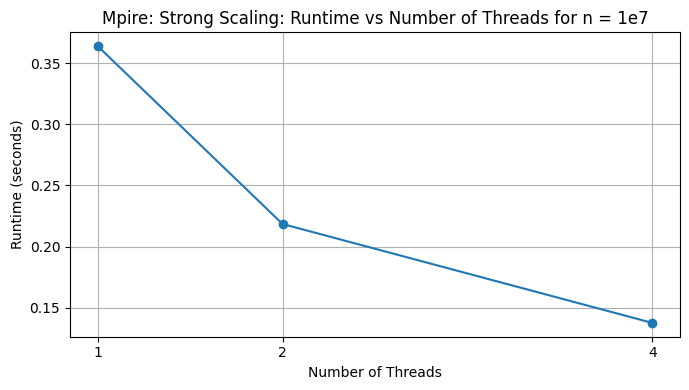

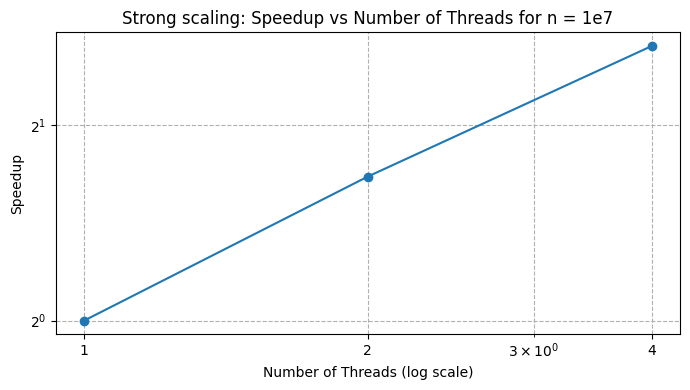

In [26]:
import importlib
import mpire_lorentz
importlib.reload(mpire_lorentz)
import timeit

import matplotlib.pyplot as plt

#Strong Scaling
n=1e7
times=[]
thread_counts = [1, 2, 4]
#WARMUP RUN
local_dry_run = mpire_lorentz.run_mpire(1e7, n_jobs=1)  # Warmup run to initialize mpire
del local_dry_run  # Free memory from warmup run
for n_threads in thread_counts:
    def run_once():
        return mpire_lorentz.run_mpire(n, n_jobs=n_threads)
    
    total_time = timeit.timeit(run_once, number=5)
    avg_time = total_time / 5
    times.append(avg_time)
    print(f"Time taken with {n_threads} threads: {avg_time:.4f} seconds (avg of 5 runs)")

plot_strong_scaling(n, thread_counts, times, method_name="Mpire")

# plot speedup vs parallelism
plt.figure(figsize=(7, 4))
speedup = [times[0] / t for t in times]
plt.plot(thread_counts, speedup, marker='o')
plt.xscale('log', base=10)
plt.yscale('log', base=2)
plt.xlabel('Number of Threads (log scale)')
plt.ylabel('Speedup')
plt.title(f'Strong scaling: Speedup vs Number of Threads for n = 1e{int(np.log10(n))}')
plt.grid(True, which="both", ls="--")
plt.xticks(thread_counts, thread_counts)
plt.tight_layout()
plt.show()

Time taken with 1 threads: 0.3204 seconds (avg of 5 runs)
Time taken with 2 threads: 0.3699 seconds (avg of 5 runs)
Time taken with 4 threads: 0.3868 seconds (avg of 5 runs)


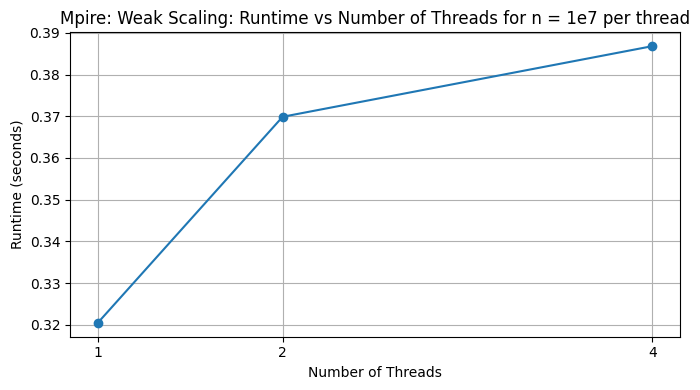

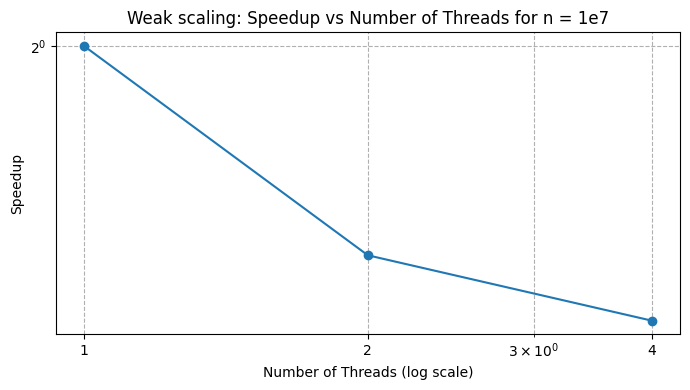

In [27]:
# Weak Scaling
n=1e7
times=[]
thread_counts = [1, 2, 4]
#WARMUP RUN to initialize mpire
local_dry_run = mpire_lorentz.run_mpire(n, n_jobs=1)
del local_dry_run  # Free memory from warmup run
for n_threads in thread_counts:
    def run_once():
        return mpire_lorentz.run_mpire(n*n_threads, n_jobs=n_threads)
    
    total_time = timeit.timeit(run_once, number=5)
    avg_time = total_time / 5
    times.append(avg_time)
    print(f"Time taken with {n_threads} threads: {avg_time:.4f} seconds (avg of 5 runs)")

plot_weak_scaling(n, thread_counts, times, method_name="Mpire")

# plot speedup vs parallelism
plt.figure(figsize=(7, 4))
speedup = [times[0] / t for t in times]
plt.plot(thread_counts, speedup, marker='o')
plt.xscale('log', base=10)
plt.yscale('log', base=2)
plt.xlabel('Number of Threads (log scale)')
plt.ylabel('Speedup')
plt.title(f'Weak scaling: Speedup vs Number of Threads for n = 1e{int(np.log10(n))}')
plt.grid(True, which="both", ls="--")
plt.xticks(thread_counts, thread_counts)
plt.tight_layout()
plt.show()